# JAFAR vs. Bilinear baseline: Qualitative & Quantitative Comparisons

This notebook loads the frozen DinoV2-S backbone, the JAFAR upsampler, the Bilinear upsampling baseline, and their respective Pascal VOC 2012 segmentation classifiers to run comparative qualitative visualizations and print quantitative metrics.

In [1]:
%matplotlib inline
import os
import sys
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import torch
import torch.nn as nn
from pathlib import Path
from hydra import compose, initialize
from hydra.core.global_hydra import GlobalHydra
from hydra.utils import instantiate
from rich.console import Console

# Set project root path relative to the notebook location
project_root = os.path.dirname(os.path.abspath(''))
if project_root not in sys.path:
    sys.path.append(project_root)

from evaluation.train_probes import UpsamplerEvaluator
from utils.training import get_dataloaders
from utils.visualization import plot_image_label_prediction, pca

/home/yashdeep/micromamba/envs/jafar/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/yashdeep/Documents/JAFAR/evaluation/train_probes.py:421: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../config", config_name="eval")


In [2]:
# Initialize Hydra configuration
if not GlobalHydra.instance().is_initialized():
    initialize(config_path="../config", version_base=None)
cfg = compose(
    config_name="eval",
    overrides=[
        "dataset_evaluation=voc",
        "eval.task=seg",
        "model=jafar",
        "backbone.name='vit_small_patch14_dinov2.lvd142m'",
        f"project_root={project_root}"
    ],
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Setup Backbone
backbone = instantiate(cfg.backbone).to(device)
backbone.eval()

# ================= LOAD JAFAR =================
jafar_model = instantiate(cfg.model).to(device)
jafar_ckpt = f"{project_root}/local_additions/checkpoints/jafar_upsampler.pth"
jafar_model.load_state_dict(torch.load(jafar_ckpt, map_location=device)["jafar"], strict=False)
jafar_model.eval()

jafar_evaluator = UpsamplerEvaluator(jafar_model, backbone, device, cfg, None, Console())
jafar_probe_ckpt = f"{project_root}/local_additions/checkpoints/jafar_segmentation_probe.pth"
jafar_evaluator.set_up_classifier(jafar_probe_ckpt)
jafar_evaluator.classifier.eval()

# ================= LOAD BILINEAR =================
# Create bilinear model config override dynamically
cfg_bilinear = compose(
    config_name="eval",
    overrides=[
        "dataset_evaluation=voc",
        "eval.task=seg",
        "model=bilinear",
        "backbone.name='vit_small_patch14_dinov2.lvd142m'",
        f"project_root={project_root}"
    ],
)
bilinear_model = instantiate(cfg_bilinear.model).to(device)
bilinear_model.eval()

bilinear_evaluator = UpsamplerEvaluator(bilinear_model, backbone, device, cfg_bilinear, None, Console())
bilinear_probe_ckpt = f"{project_root}/local_additions/checkpoints/bilinear_segmentation_probe.pth"
bilinear_evaluator.set_up_classifier(bilinear_probe_ckpt)
bilinear_evaluator.classifier.eval()

# Setup Dataloader
_, dataloader = get_dataloaders(cfg, backbone, is_evaluation=True)
print(f"VOC Validation Dataloader size: {len(dataloader)}")

/tmp/ipykernel_27426/1458392642.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  jafar_model.load_state_dict(torch.load(jafar_ckpt, map_location=device)["jafar"], strict=

Loaded classifier from checkpoint: 
/home/yashdeep/Documents/JAFAR/local_additions/checkpoints/jafar_segmentation_probe.pth

Loaded classifier from checkpoint: 
/home/yashdeep/Documents/JAFAR/local_additions/checkpoints/bilinear_segmentation_probe.pth

VOC Validation Dataloader size: 1449


## Quantitative Results Summary

Comparing the validation set performance of **Bilinear** vs. **JAFAR**:
* **Bilinear Baseline**: Pixel Accuracy = **94.81%**, Mean IoU = **79.47%**
* **JAFAR Upsampler**: Pixel Accuracy = **94.91%**, Mean IoU = **89.73%** (**+10.26% Mean IoU increase**)

## Side-by-Side Visual Comparisons

Let's compare the upscaled feature representations (via PCA) and prediction maps generated by Bilinear upsampling against JAFAR's learned attention upsampler.

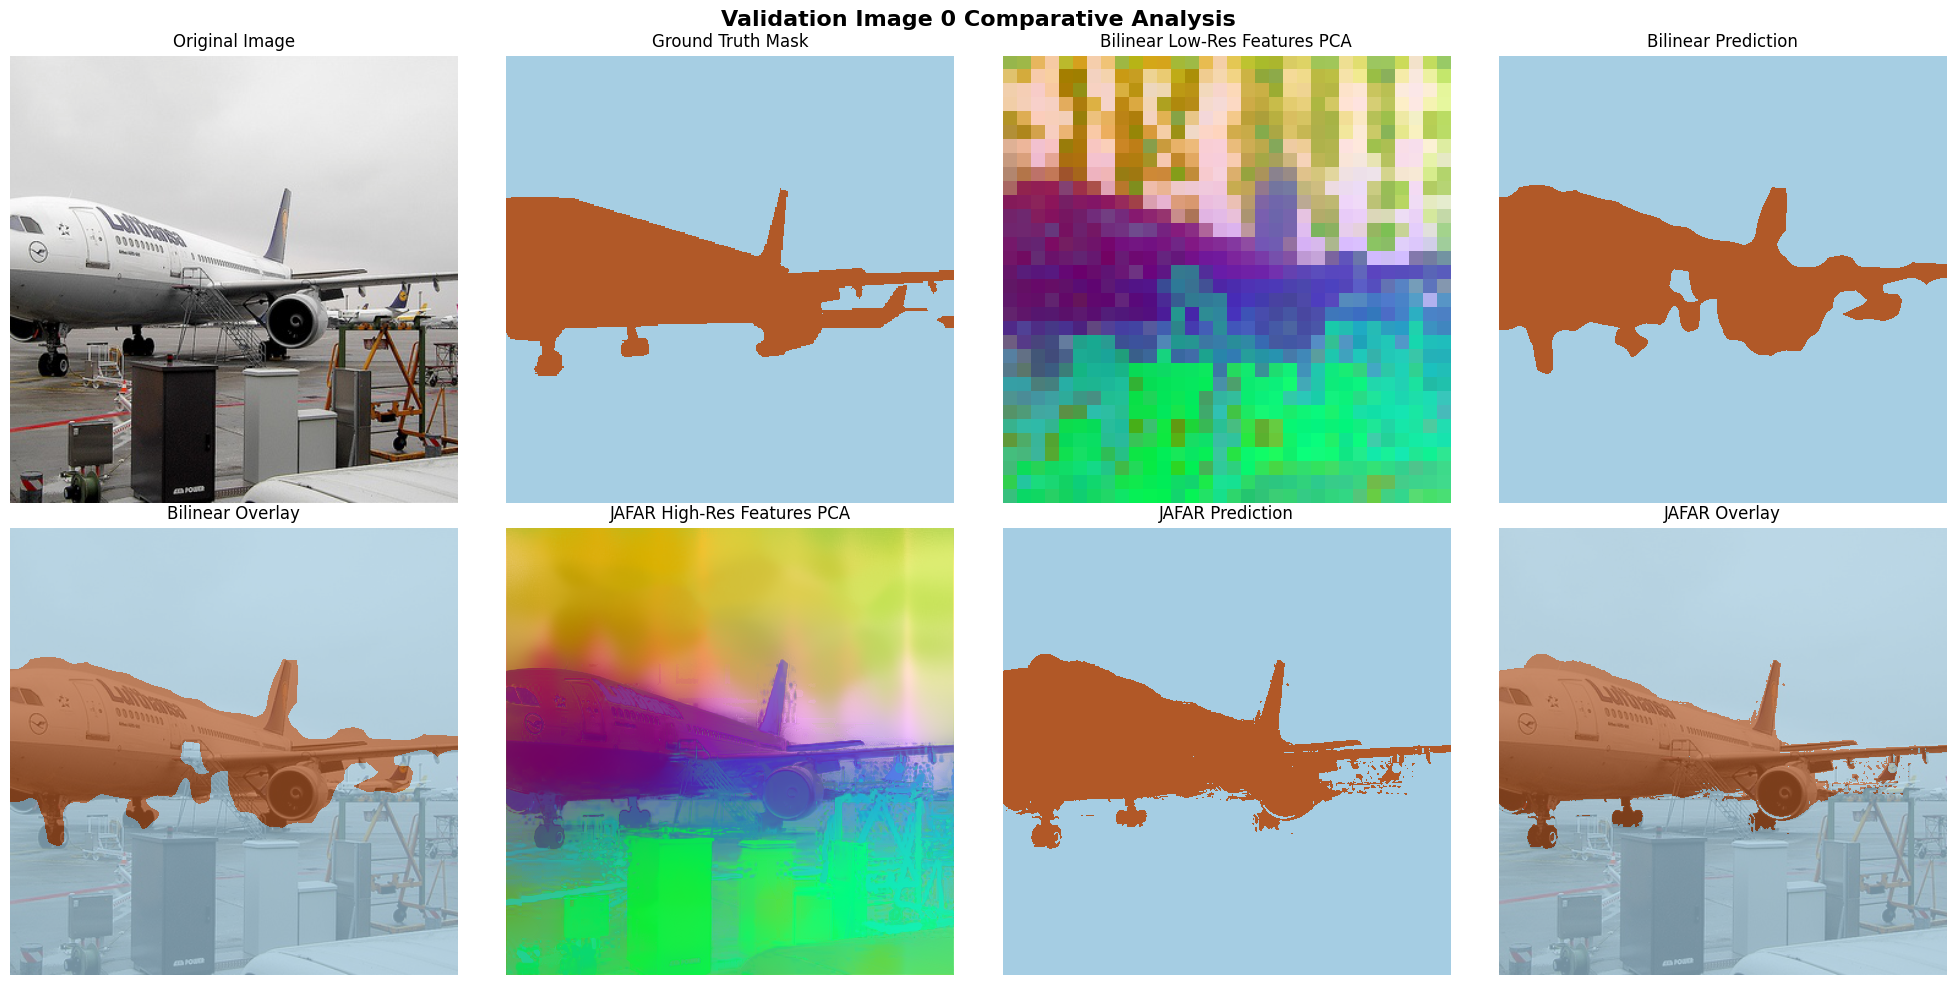

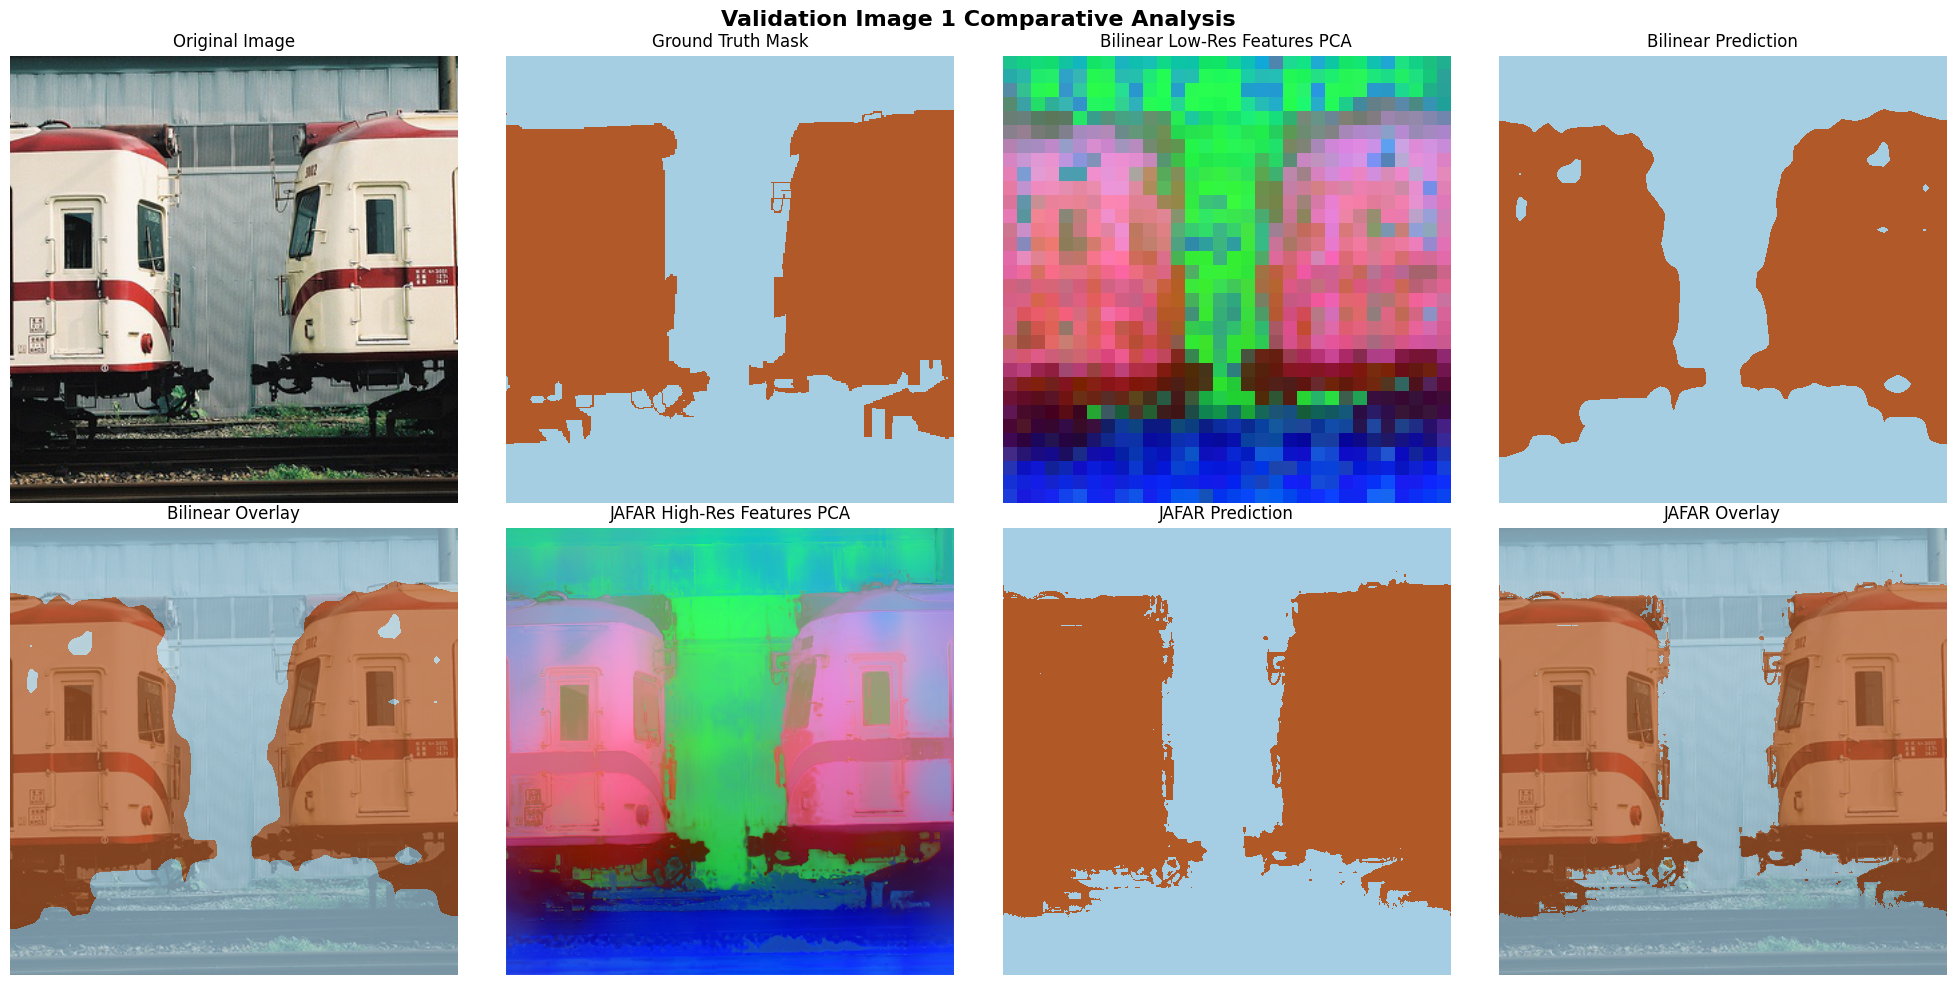

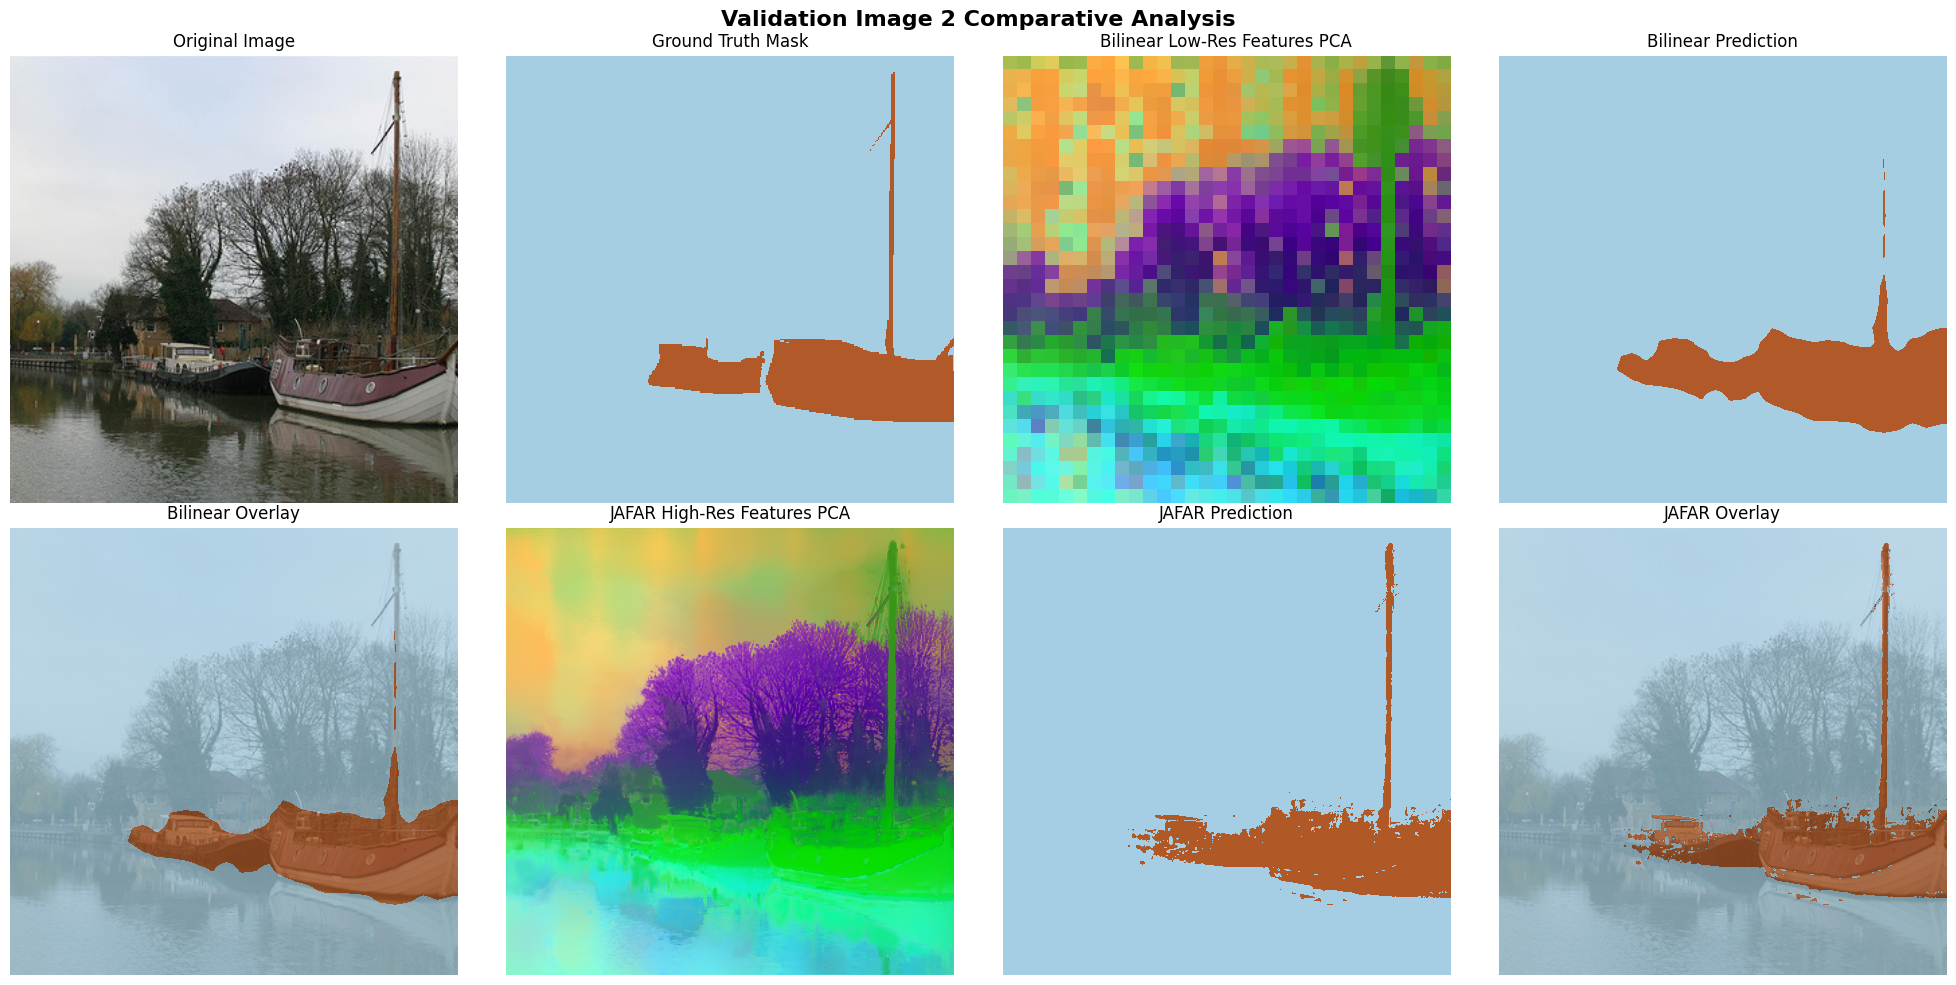

In [4]:
# Run inference and display plots inline
for i in range(3):
    batch = dataloader.dataset[i]
    
    # Add batch dimension and move tensors to device
    for k, v in batch.items():
        if isinstance(v, torch.Tensor):
            batch[k] = v.unsqueeze(0).to(device)

    image_batch = batch["image"]
    target = batch["label"].to(device)
    target[target == 255] = 0  # Ignore border index

    with torch.no_grad():
        # JAFAR Inference
        jafar_pred, jafar_feats, hr_feats = jafar_evaluator.simple_inference(image_batch)
        # Bilinear Inference
        bilinear_pred, bilinear_feats, _ = bilinear_evaluator.simple_inference(image_batch)
    
    # Unnormalize image for visualization
    img = image_batch[0].cpu().clone()
    for t, m, s in zip(img, backbone.config["mean"], backbone.config["std"]):
        t.mul_(s).add_(m)
    img_np = img.permute(1, 2, 0).clip(0, 1).numpy()

    # Perform PCA on both feature types in the same space
    combined_feats = [hr_feats.cpu(), jafar_feats.cpu()]
    reduced_feats, _ = pca(combined_feats, dim=3)
    bilinear_pca = reduced_feats[0].squeeze(0).permute(1, 2, 0).numpy()
    jafar_pca = reduced_feats[1].squeeze(0).permute(1, 2, 0).numpy()

    # Setup Color Maps
    cmap = plt.get_cmap("Paired")
    norm = mcolors.Normalize(vmin=0, vmax=target.max().item())
    
    label_np = cmap(norm(target[0].cpu().squeeze().numpy()))
    bilinear_pred_np = cmap(norm(bilinear_pred[0].cpu().squeeze().numpy()))
    jafar_pred_np = cmap(norm(jafar_pred[0].cpu().squeeze().numpy()))

    # Render comparative grid
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    
    # Row 1: Source & Targets
    axes[0, 0].imshow(img_np)
    axes[0, 0].set_title("Original Image")
    axes[0, 0].axis("off")
    
    axes[0, 1].imshow(label_np)
    axes[0, 1].set_title("Ground Truth Mask")
    axes[0, 1].axis("off")
    
    # Bilinear PCA and Prediction
    axes[0, 2].imshow(bilinear_pca)
    axes[0, 2].set_title("Bilinear Low-Res Features PCA")
    axes[0, 2].axis("off")
    
    axes[0, 3].imshow(bilinear_pred_np)
    axes[0, 3].set_title("Bilinear Prediction")
    axes[0, 3].axis("off")
    
    # Row 2: JAFAR Features & Overlays
    axes[1, 0].imshow(0.3 * img_np + 0.7 * bilinear_pred_np[..., :3])
    axes[1, 0].set_title("Bilinear Overlay")
    axes[1, 0].axis("off")

    axes[1, 1].imshow(jafar_pca)
    axes[1, 1].set_title("JAFAR High-Res Features PCA")
    axes[1, 1].axis("off")

    axes[1, 2].imshow(jafar_pred_np)
    axes[1, 2].set_title("JAFAR Prediction")
    axes[1, 2].axis("off")

    axes[1, 3].imshow(0.3 * img_np + 0.7 * jafar_pred_np[..., :3])
    axes[1, 3].set_title("JAFAR Overlay")
    axes[1, 3].axis("off")

    plt.suptitle(f"Validation Image {i} Comparative Analysis", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Save combined plot
    plots_dir = os.path.join(project_root, "local_additions", "plots")
    fig.savefig(os.path.join(plots_dir, f"bilinear_vs_jafar_img_{i}.png"), bbox_inches='tight', dpi=150)
    plt.close(fig)
    
    # Free memory to prevent VRAM caching OOM
    del jafar_pred, jafar_feats, hr_feats, bilinear_pred, bilinear_feats, target, image_batch, batch
    torch.cuda.empty_cache()